In [1]:
%pip install -r utils/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from pathlib import Path

# Set up paths - Data is in utils/Data/Clean/
waldo_path = '/workspaces/wheres-wally/utils/Data/Clean/ClearedWaldos/'
heads_path = '/workspaces/wheres-wally/utils/Data/Clean/OnlyWaldoHeads/'

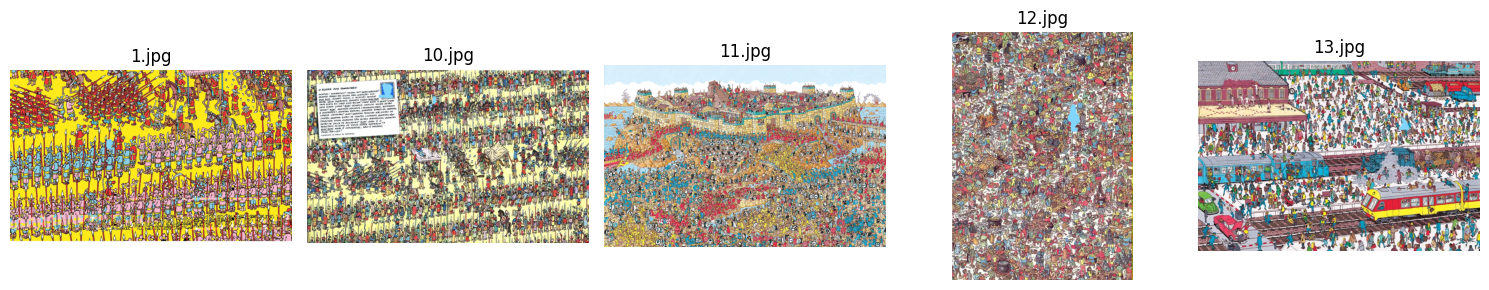

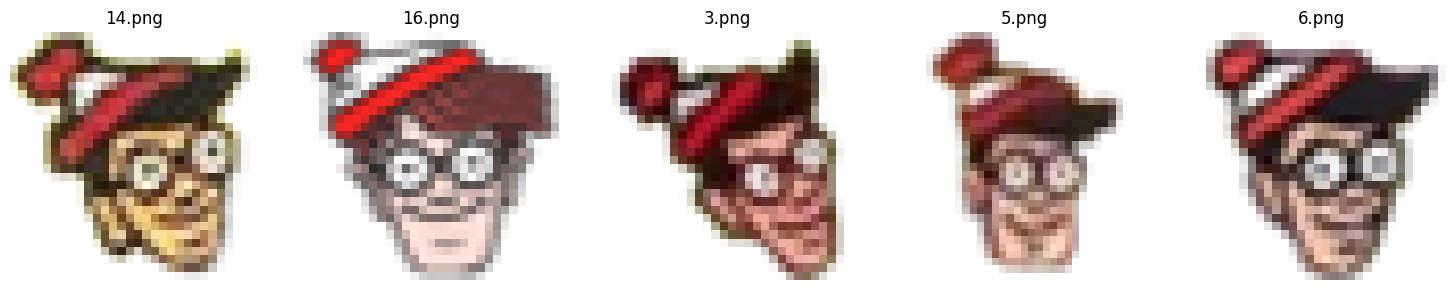

In [3]:
# Display examples of Only Wally
waldo_files = sorted([f for f in os.listdir(waldo_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(waldo_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(waldo_files[:num_samples]):
    img = mpimg.imread(os.path.join(waldo_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Display examples of Only Wally Heads
heads_files = sorted([f for f in os.listdir(heads_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(heads_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(heads_files[:num_samples]):
    img = mpimg.imread(os.path.join(heads_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import os
import sys

os.chdir('/workspaces/wheres-wally/utils')
sys.path.insert(0, '/workspaces/wheres-wally/utils')

try:
    from DataAugmentation import generating_waldos
    generating_waldos(use_background=True, variations_per_combo=2, max_images=100, 
                      max_heads=3, max_backgrounds=15, sample_ratio=1)
except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")
    import traceback
    traceback.print_exc()

Data path: /workspaces/wheres-wally/utils/Data
Found 6 head images, 33 background images
Using 3 heads × 15 backgrounds × 2 variations
Will generate up to 90 total images


Progress: 50/90 images generated (55%)

Generated 90 training images
  - 90 Waldo images saved to /workspaces/wheres-wally/utils/Data/Waldo
  - 90 NotWaldo images saved to /workspaces/wheres-wally/utils/Data/NotWaldo


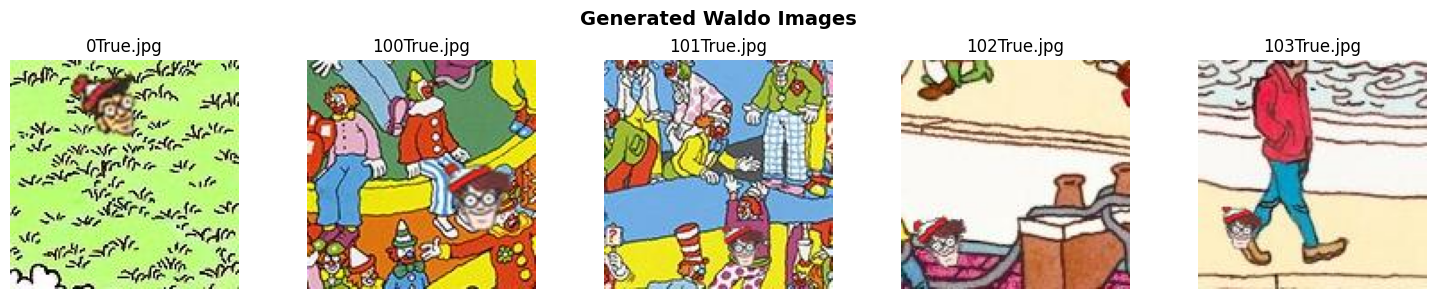

In [5]:
# List the generated Waldo images from the DataAugmentation output
waldo_generated_files = sorted([f for f in os.listdir('/workspaces/wheres-wally/utils/Data/Waldo') if f.endswith('.jpg')])[:5]

# Display 5 images from the generated Waldo dataset
fig, axes = plt.subplots(1, len(waldo_generated_files), figsize=(15, 3))
fig.suptitle('Generated Waldo Images', fontsize=14, fontweight='bold')

for idx, file in enumerate(waldo_generated_files):
    img = mpimg.imread(os.path.join('/workspaces/wheres-wally/utils/Data/Waldo', file))
    if len(waldo_generated_files) == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import sys
from pathlib import Path
import gc

# Define and add utils directory to Python path
utils_path = '/workspaces/wheres-wally/utils'
if utils_path not in sys.path:
    sys.path.insert(0, utils_path)

from TrainModel import train_waldo_model

# Clear any existing memory
gc.collect()

# Create simple output directory
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

save_path = output_dir / 'waldo_model.weights.h5'  # Fixed: must end in .weights.h5
data_dir = Path(utils_path) / 'Data'

# Train model from scratch with reduced epochs to prevent crashes
print("Training Waldo detection model from scratch...")
model, X_test, Y_test, score = train_waldo_model(
    data_path=str(data_dir),
    epochs=20,  # Reduced from 15 to 5 to prevent kernel crash
    test_size=0.10,
    save_path=str(save_path)
)
print(f"✓ Model saved to: {save_path}")

2026-01-29 12:17:54.587780: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 12:17:54.588608: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 12:17:54.591720: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 12:17:54.599076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-29 12:17:54.611457: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Training Waldo detection model from scratch...
Loading Waldo images (label=1)...
Loading NotWaldo images (label=0)...

Total images: 792
Waldo images: 396.0, NotWaldo images: 396.0
Data loading time: 0.91 seconds

X_train shape: (712, 64, 64, 3)
X_test shape: (80, 64, 64, 3)

Training model...
Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.4817 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.4803 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.4691 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.500